In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Untuk preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

np.random.seed(42)

print(" Library berhasil diimport!")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")



 Library berhasil diimport!
   NumPy   : 1.26.4
   Pandas  : 2.3.3


## 2.  Load Dataset

In [8]:
df = pd.read_csv('../data/ raw/bank/bank-full.csv', sep=';')

print(f"Shape dataset : {df.shape}")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()


Shape dataset : (45211, 17)
Jumlah baris  : 45,211
Jumlah kolom  : 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
print("=== TIPE DATA ===")
print(df.dtypes)
print("\n=== DISTRIBUSI TARGET ===")
dist = df['y'].value_counts()
print(dist)
print(f"\nRasio imbalanced: {dist['no']/dist['yes']:.1f}:1 (no:yes)")


=== TIPE DATA ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

=== DISTRIBUSI TARGET ===
y
no     39922
yes     5289
Name: count, dtype: int64

Rasio imbalanced: 7.5:1 (no:yes)


## 3. Exploratory Data Analysis (EDA)

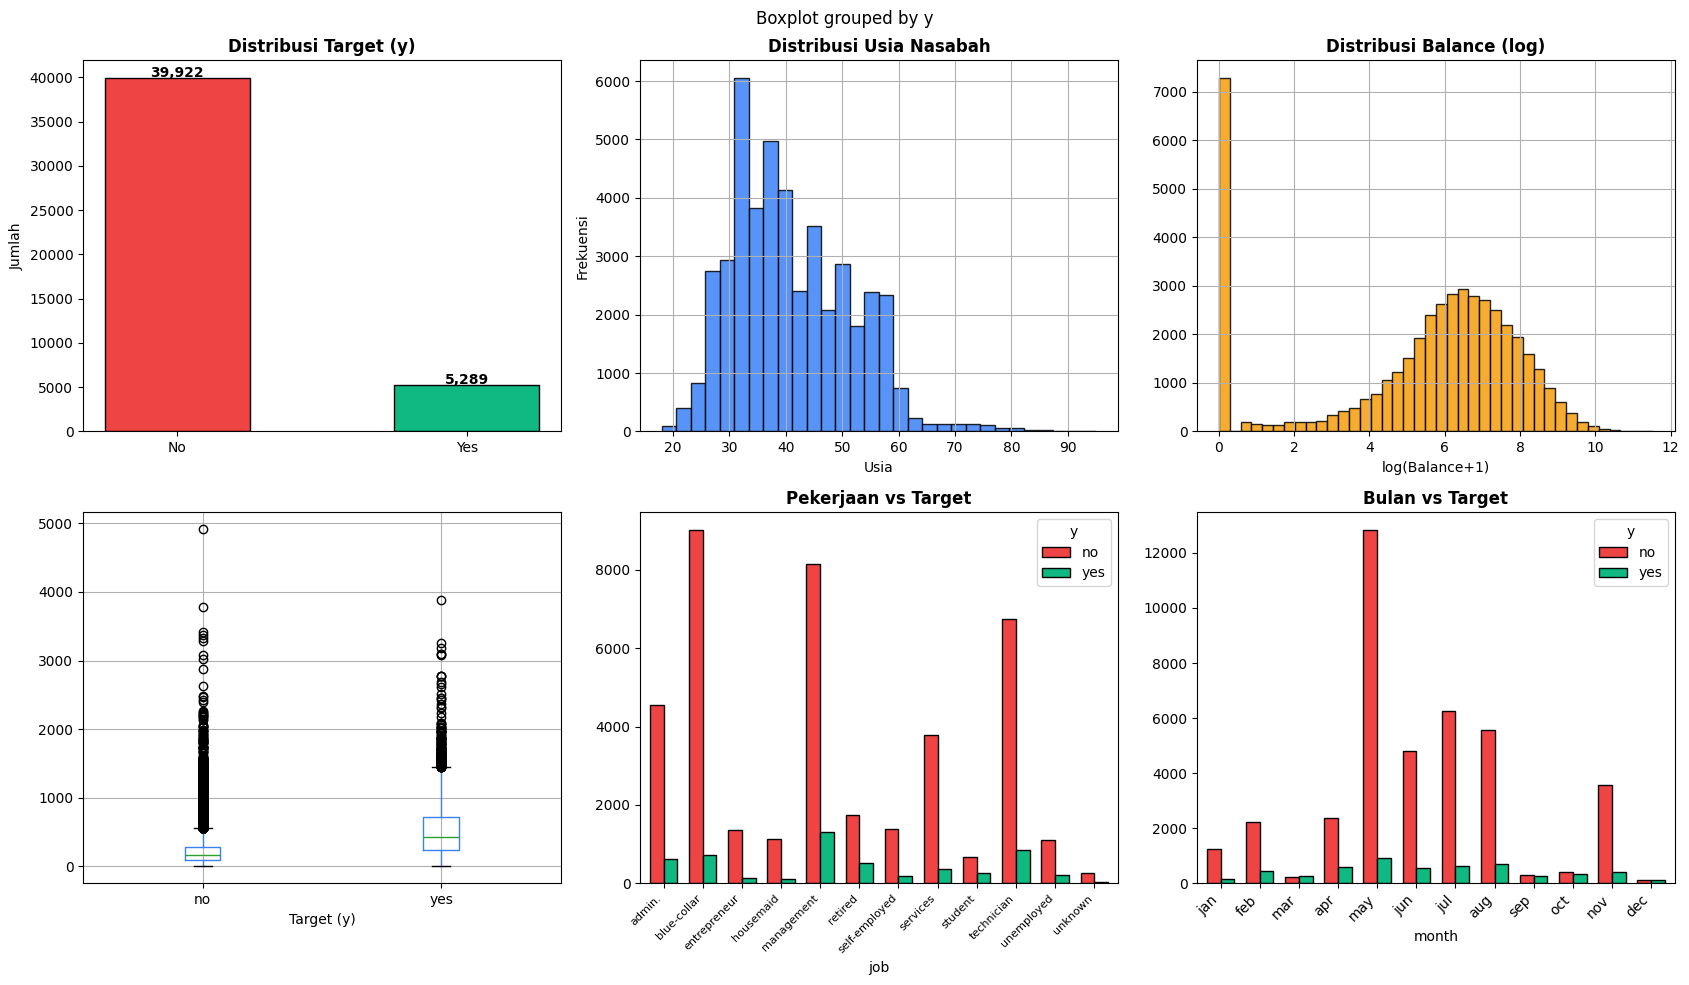

✅ EDA selesai.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Exploratory Data Analysis — bank-full.csv', fontsize=14, fontweight='bold')

dist = df['y'].value_counts()

# 1. Target distribution
axes[0,0].bar(['No','Yes'], dist.values, color=['#ef4444','#10b981'], edgecolor='black', width=0.5)
axes[0,0].set_title('Distribusi Target (y)', fontweight='bold')
axes[0,0].set_ylabel('Jumlah')
for i, v in enumerate(dist.values):
    axes[0,0].text(i, v+100, f'{v:,}', ha='center', fontweight='bold')

# 2. Age distribution
df['age'].hist(ax=axes[0,1], bins=30, color='#3b82f6', edgecolor='black', alpha=0.85)
axes[0,1].set_title('Distribusi Usia Nasabah', fontweight='bold')
axes[0,1].set_xlabel('Usia'); axes[0,1].set_ylabel('Frekuensi')

# 3. Balance distribution (log scale)
df['balance'].clip(lower=0).apply(lambda x: np.log1p(x)).hist(
    ax=axes[0,2], bins=40, color='#f59e0b', edgecolor='black', alpha=0.85)
axes[0,2].set_title('Distribusi Balance (log)', fontweight='bold')
axes[0,2].set_xlabel('log(Balance+1)')

# 4. Duration vs Target
df.boxplot(column='duration', by='y', ax=axes[1,0],
           boxprops=dict(color='#3b82f6'),
           whiskerprops=dict(color='#3b82f6'))
axes[1,0].set_title('Durasi Panggilan vs Target', fontweight='bold')
axes[1,0].set_xlabel('Target (y)'); plt.sca(axes[1,0]); plt.title('')

# 5. Job vs Target
job_target = df.groupby(['job','y']).size().unstack(fill_value=0)
job_target.plot(kind='bar', ax=axes[1,1], color=['#ef4444','#10b981'], edgecolor='black', width=0.7)
axes[1,1].set_title('Pekerjaan vs Target', fontweight='bold')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# 6. Month vs Target
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_target = df.groupby(['month','y']).size().unstack(fill_value=0)
month_target = month_target.reindex([m for m in month_order if m in month_target.index])
month_target.plot(kind='bar', ax=axes[1,2], color=['#ef4444','#10b981'], edgecolor='black', width=0.7)
axes[1,2].set_title('Bulan vs Target', fontweight='bold')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA selesai.")


## 4. Preprocessing Data

In [11]:
num_cols = ['age','balance','day','duration','campaign','pdays','previous']
bin_cols = ['default','housing','loan']
cat_cols = ['job','marital','education','contact','month','poutcome']
target   = 'y'

df_proc = df.copy()

# 1. Biner → 0/1
le = LabelEncoder()
for col in bin_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

# 2. Kategorik → One-Hot Encoding (manual dengan pd.get_dummies)
df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=False)

# 3. Target → 0/1
df_proc[target] = (df_proc[target] == 'yes').astype(int)

print(f"Shape setelah encoding : {df_proc.shape}")
print(f"Jumlah fitur input     : {df_proc.shape[1] - 1} neuron")


Shape setelah encoding : (45211, 49)
Jumlah fitur input     : 48 neuron


In [12]:
X = df_proc.drop(columns=[target]).values.astype(np.float64)
y = df_proc[target].values.astype(np.float64)

# Normalisasi dengan StandardScaler (untuk preprocessing saja, bukan model)
scaler = StandardScaler()
num_idx = [df_proc.drop(columns=[target]).columns.tolist().index(c) for c in num_cols]
X[:, num_idx] = scaler.fit_transform(X[:, num_idx])

# Train/Test split 80:20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah fitur (neuron input) : {X.shape[1]}")
print(f"X_train : {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\nKelas train -> No: {int((y_train==0).sum()):,} | Yes: {int((y_train==1).sum()):,}")


Jumlah fitur (neuron input) : 48
X_train : (36168, 48)  |  y_train: (36168,)
X_test  : (9043, 48)   |  y_test : (9043,)

Kelas train -> No: 31,937 | Yes: 4,231


## 5. Visualisasi Arsitektur Neural Network

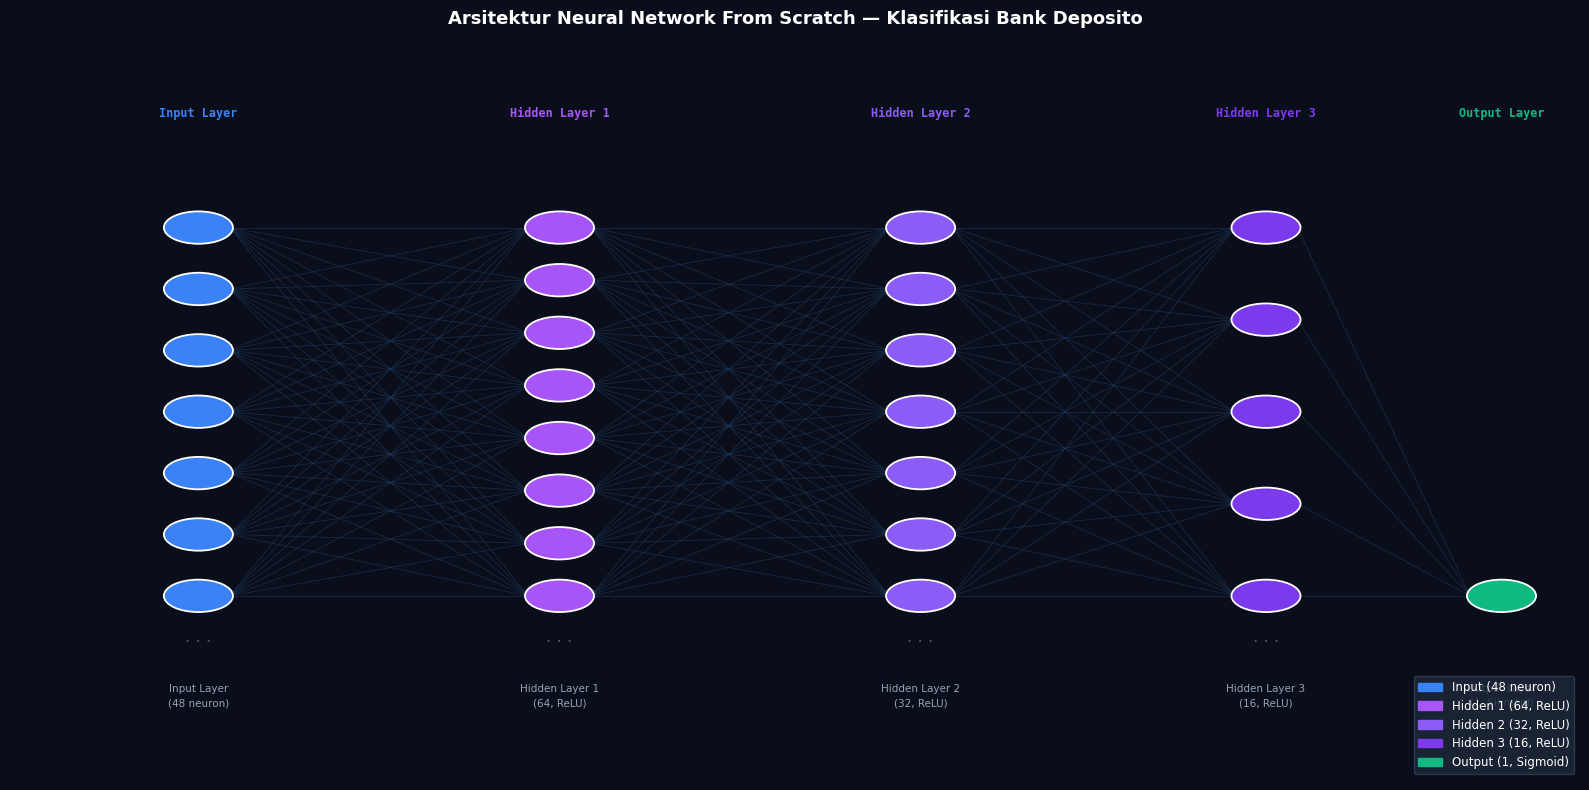

✅ Diagram arsitektur tersimpan.


In [ ]:
def draw_architecture(input_dim):
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    ax.set_facecolor('#0a0e1a'); fig.patch.set_facecolor('#0a0e1a')

    layers_cfg = [
        {'label': f'Input Layer\n({input_dim} neuron)', 'n': 7, 'x': 1.2,  'color': '#3b82f6'},
        {'label': 'Hidden Layer 1\n(64, ReLU)',          'n': 8, 'x': 3.5,  'color': '#a855f7'},
        {'label': 'Hidden Layer 2\n(32, ReLU)',          'n': 7, 'x': 5.8,  'color': '#8b5cf6'},
        {'label': 'Hidden Layer 3\n(16, ReLU)',          'n': 5, 'x': 8.0,  'color': '#7c3aed'},
        {'label': 'Output Layer\n(1, Sigmoid)',          'n': 1, 'x': 9.5,  'color': '#10b981'},
    ]

    positions = []
    for cfg in layers_cfg:
        ys = np.linspace(2.5, 7.5, cfg['n'])
        positions.append((cfg['x'], ys))

    for i in range(len(positions)-1):
        x1, ys1 = positions[i]; x2, ys2 = positions[i+1]
        for y1 in ys1:
            for y2 in ys2:
                ax.plot([x1+0.2, x2-0.2], [y1, y2], color='#1e3a5f', lw=0.6, alpha=0.6)

    for idx, cfg in enumerate(layers_cfg):
        x, ys = positions[idx]
        for y in ys:
            ax.add_patch(plt.Circle((x, y), 0.22, color=cfg['color'], ec='white', lw=1.3, zorder=3))
        ax.text(x, 9.0, cfg['label'].split('\n')[0],
                ha='center', color=cfg['color'], fontsize=8.5, fontweight='bold', fontfamily='monospace')
        ax.text(x, 1.0, cfg['label'], ha='center', color='#94a3b8', fontsize=7.5, linespacing=1.5)
        if idx < 4:
            ax.text(x, 1.8, '· · ·', ha='center', color='#475569', fontsize=12)

    ax.set_title('Arsitektur Neural Network From Scratch — Klasifikasi Bank Deposito',
                 color='white', fontsize=13, fontweight='bold', pad=14)

    legend = [
        mpatches.Patch(color='#3b82f6', label=f'Input ({input_dim} neuron)'),
        mpatches.Patch(color='#a855f7', label='Hidden 1 (64, ReLU)'),
        mpatches.Patch(color='#8b5cf6', label='Hidden 2 (32, ReLU)'),
        mpatches.Patch(color='#7c3aed', label='Hidden 3 (16, ReLU)'),
        mpatches.Patch(color='#10b981', label='Output (1, Sigmoid)'),
    ]
    ax.legend(handles=legend, loc='lower right', facecolor='#1e293b',
              edgecolor='#334155', labelcolor='white', fontsize=8.5)

    plt.tight_layout()
    plt.savefig('nn_architecture.png', dpi=130, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print("Diagram arsitektur tersimpan.")

draw_architecture(X_train.shape[1])


## 6. Neural Network dari Scratch (Pure NumPy)

Seluruh komponen NN diimplementasikan manual:
- **Fungsi Aktivasi**: ReLU & Sigmoid
- **Forward Propagation**: hitung output layer per layer
- **Loss Function**: Binary Cross-Entropy
- **Backward Propagation**: hitung gradien dengan chain rule
- **Weight Update**: Gradient Descent dengan Momentum (Adam)


In [ ]:
# ─────────────────────────────────────────────────────────────
# FUNGSI AKTIVASI
# ─────────────────────────────────────────────────────────────

def relu(Z):
    """ReLU: f(x) = max(0, x)"""
    return np.maximum(0, Z)

def relu_derivative(Z):
    """Turunan ReLU: f'(x) = 1 jika x > 0, else 0"""
    return (Z > 0).astype(float)

def sigmoid(Z):
    """Sigmoid: f(x) = 1 / (1 + e^(-x))"""
    Z = np.clip(Z, -500, 500)  # Cegah overflow
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(Z):
    """Turunan Sigmoid: f'(x) = f(x) * (1 - f(x))"""
    s = sigmoid(Z)
    return s * (1 - s)

# ─────────────────────────────────────────────────────────────
# LOSS FUNCTION
# ─────────────────────────────────────────────────────────────

def binary_cross_entropy(y_true, y_pred):
    """BCE: -[ y*log(p) + (1-y)*log(1-p) ]"""
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

print(" Fungsi aktivasi & loss didefinisikan")
print()
# Demo fungsi aktivasi
z_demo = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
print(f"  z          : {z_demo}")
print(f"  ReLU(z)    : {relu(z_demo)}")
print(f"  Sigmoid(z) : {np.round(sigmoid(z_demo), 4)}")


✅ Fungsi aktivasi & loss didefinisikan

  z          : [-3. -1.  0.  1.  3.]
  ReLU(z)    : [0. 0. 0. 1. 3.]
  Sigmoid(z) : [0.0474 0.2689 0.5    0.7311 0.9526]


In [ ]:
# ─────────────────────────────────────────────────────────────
# INISIALISASI PARAMETER (He Initialization)
# ─────────────────────────────────────────────────────────────

def initialize_parameters(layer_dims):
    """
    He Initialization untuk layer dengan ReLU.
    layer_dims: list jumlah neuron per layer, contoh [48, 64, 32, 16, 1]
    
    Return dict berisi W dan b untuk setiap layer.
    """
    np.random.seed(42)
    params = {}
    L = len(layer_dims) - 1  # Jumlah layer (tidak termasuk input)

    for l in range(1, L + 1):
        n_in  = layer_dims[l-1]
        n_out = layer_dims[l]

        # He initialization: W ~ N(0, sqrt(2/n_in))
        params[f'W{l}'] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
        params[f'b{l}'] = np.zeros((n_out, 1))

    return params

# ─────────────────────────────────────────────────────────────
# FORWARD PROPAGATION
# ─────────────────────────────────────────────────────────────

def forward_propagation(X, params):
    """
    Hitung output dari setiap layer secara berurutan.
    
    Layer 1,2,3 : ReLU
    Layer 4     : Sigmoid (output)
    
    Return:
        AL    : output akhir (prediksi)
        cache : menyimpan Z dan A tiap layer untuk backprop
    """
    cache = {}
    A = X.T                    # shape: (n_features, n_samples)
    L = len(params) // 2       # jumlah layer

    for l in range(1, L + 1):
        W = params[f'W{l}']
        b = params[f'b{l}']
        Z = W @ A + b          # Linear: Z = W*A + b
        cache[f'Z{l}'] = Z
        cache[f'A{l-1}'] = A

        if l < L:
            A = relu(Z)        # Hidden layers: ReLU
        else:
            A = sigmoid(Z)     # Output layer: Sigmoid

    AL = A.flatten()           # shape: (n_samples,)
    return AL, cache

print(" Forward propagation didefinisikan")


✅ Forward propagation didefinisikan


In [ ]:
# ─────────────────────────────────────────────────────────────
# BACKWARD PROPAGATION
# ─────────────────────────────────────────────────────────────

def backward_propagation(y_true, AL, cache, params):
    """
    Hitung gradien semua bobot menggunakan chain rule.
    
    dL/dW = dL/dA * dA/dZ * dZ/dW
    dL/db = dL/dA * dA/dZ
    
    Return:
        grads : dict gradien dW dan db untuk setiap layer
    """
    grads = {}
    m  = len(y_true)            # Jumlah sampel
    L  = len(params) // 2       # Jumlah layer
    eps = 1e-8

    # Gradien output layer (Sigmoid + BCE)
    # dL/dA_L = -(y/AL - (1-y)/(1-AL)) * (1/m)
    AL_clipped = np.clip(AL, eps, 1-eps)
    dAL = -(y_true / AL_clipped - (1 - y_true) / (1 - AL_clipped)) / m

    # Gradien Z_L (turunan Sigmoid)
    Z_L   = cache[f'Z{L}']
    dZ    = dAL * sigmoid_derivative(Z_L.flatten())
    dZ    = dZ.reshape(1, -1)

    # Loop mundur dari layer L ke layer 1
    for l in range(L, 0, -1):
        A_prev = cache[f'A{l-1}']   # Aktivasi dari layer sebelumnya
        W      = params[f'W{l}']

        grads[f'dW{l}'] = dZ @ A_prev.T   # Gradien bobot
        grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True)  # Gradien bias
        
        if l > 1:
            # Propagasikan gradien ke layer sebelumnya
            dA_prev = W.T @ dZ
            Z_prev  = cache[f'Z{l-1}']
            dZ      = dA_prev * relu_derivative(Z_prev)

    return grads

print("Backward propagation didefinisikan")


✅ Backward propagation didefinisikan


In [ ]:
# ─────────────────────────────────────────────────────────────
# ADAM OPTIMIZER (dari scratch)
# ─────────────────────────────────────────────────────────────

def initialize_adam(params):
    """Inisialisasi momen pertama (m) dan kedua (v) untuk Adam."""
    L = len(params) // 2
    adam_state = {}
    for l in range(1, L+1):
        adam_state[f'mW{l}'] = np.zeros_like(params[f'W{l}'])
        adam_state[f'mb{l}'] = np.zeros_like(params[f'b{l}'])
        adam_state[f'vW{l}'] = np.zeros_like(params[f'W{l}'])
        adam_state[f'vb{l}'] = np.zeros_like(params[f'b{l}'])
    return adam_state

def update_adam(params, grads, adam_state, t,
                lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Update parameter menggunakan Adam optimizer.
    
    m_t = beta1*m_{t-1} + (1-beta1)*g        # First moment (momentum)
    v_t = beta2*v_{t-1} + (1-beta2)*g^2      # Second moment (RMSProp)
    m_hat = m_t / (1 - beta1^t)              # Bias correction
    v_hat = v_t / (1 - beta2^t)              # Bias correction
    theta = theta - lr * m_hat / (sqrt(v_hat) + eps)
    """
    L = len(params) // 2
    beta1_t = beta1 ** t
    beta2_t = beta2 ** t

    for l in range(1, L+1):
        for p in ['W', 'b']:
            g  = grads[f'd{p}{l}']
            m_ = adam_state[f'm{p}{l}']
            v_ = adam_state[f'v{p}{l}']

            # Update moments
            m_new = beta1 * m_ + (1 - beta1) * g
            v_new = beta2 * v_ + (1 - beta2) * (g ** 2)
            adam_state[f'm{p}{l}'] = m_new
            adam_state[f'v{p}{l}'] = v_new

            # Bias correction
            m_hat = m_new / (1 - beta1_t)
            v_hat = v_new / (1 - beta2_t)

            # Update parameter
            params[f'{p}{l}'] -= lr * m_hat / (np.sqrt(v_hat) + eps)

    return params, adam_state

print(" Adam Optimizer dari scratch didefinisikan")


✅ Adam Optimizer dari scratch didefinisikan


In [ ]:
# ─────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────

def train_neural_network(X_train, y_train, X_val, y_val,
                         layer_dims, epochs=100, batch_size=64,
                         lr=0.001, patience=10, verbose=True):
    """
    Training Neural Network dari scratch dengan:
    - Mini-batch Gradient Descent
    - Adam Optimizer
    - Early Stopping
    - Class Weighting (untuk imbalanced data)
    """
    # Inisialisasi
    params     = initialize_parameters(layer_dims)
    adam_state = initialize_adam(params)
    t          = 0        # Adam timestep

    # Class weight untuk imbalanced data (manual)
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    w_pos = (n_neg + n_pos) / (2 * n_pos)   # Bobot kelas positif
    w_neg = (n_neg + n_pos) / (2 * n_neg)   # Bobot kelas negatif

    best_val_loss = np.inf
    patience_cnt  = 0
    best_params   = None

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  [],
               'val_auc':    []}

    n_batches = int(np.ceil(len(y_train) / batch_size))

    for epoch in range(1, epochs + 1):
        # Shuffle data setiap epoch
        idx = np.random.permutation(len(y_train))
        X_shuf, y_shuf = X_train[idx], y_train[idx]

        epoch_loss = 0.0

        for b in range(n_batches):
            start = b * batch_size
            end   = start + batch_size
            Xb = X_shuf[start:end]
            yb = y_shuf[start:end]

            # Forward pass
            AL, cache = forward_propagation(Xb, params)

            # Weighted Binary Cross-Entropy
            eps_   = 1e-8
            AL_c   = np.clip(AL, eps_, 1-eps_)
            w_vec  = np.where(yb == 1, w_pos, w_neg)
            loss_b = -np.mean(w_vec * (yb * np.log(AL_c) + (1-yb) * np.log(1-AL_c)))
            epoch_loss += loss_b

            # Backward pass
            grads = backward_propagation(yb, AL, cache, params)

            # Adam update
            t += 1
            params, adam_state = update_adam(params, grads, adam_state, t, lr=lr)

        # ── Evaluasi per epoch ──
        train_pred, _ = forward_propagation(X_train, params)
        val_pred,   _ = forward_propagation(X_val,   params)

        train_loss = binary_cross_entropy(y_train, train_pred)
        val_loss   = binary_cross_entropy(y_val,   val_pred)
        train_acc  = np.mean((train_pred >= 0.5) == y_train)
        val_acc    = np.mean((val_pred   >= 0.5) == y_val)

        # AUC sederhana via sorted rank
        order     = np.argsort(val_pred)[::-1]
        y_sorted  = y_val[order]
        n_pos_v   = y_sorted.sum()
        n_neg_v   = len(y_sorted) - n_pos_v
        val_auc   = (np.cumsum(1 - y_sorted)[y_sorted == 1].sum() /
                     (n_pos_v * n_neg_v + 1e-8)) if n_pos_v > 0 and n_neg_v > 0 else 0.5

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        # Early Stopping
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_params   = {k: v.copy() for k, v in params.items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"Epoch {epoch:>3}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        if patience_cnt >= patience:
            if verbose:
                print(f"\n⏹️  Early stopping pada epoch {epoch} "
                      f"(val_loss tidak membaik selama {patience} epoch)")
            break

    return best_params, history

print(" Training loop dari scratch siap!")


✅ Training loop dari scratch siap!


## 7. Jalankan Training

In [ ]:
# Arsitektur: Input → 64 → 32 → 16 → 1
input_dim   = X_train.shape[1]
layer_dims  = [input_dim, 64, 32, 16, 1]

print("=" * 60)
print("  KONFIGURASI NEURAL NETWORK")
print("=" * 60)
print(f"  Arsitektur  : {layer_dims}")
print(f"  Input neuron: {input_dim}")
print(f"  Optimizer   : Adam (lr=0.001, β₁=0.9, β₂=0.999)")
print(f"  Loss        : Binary Cross-Entropy (Weighted)")
print(f"  Epochs      : 100 (max)")
print(f"  Batch Size  : 64")
print(f"  Early Stop  : patience=10")
print("=" * 60)
print()

# Buat validation split dari train set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"X_tr  : {X_tr.shape} | X_val : {X_val.shape}")
print()
print("Training dimulai...\n")

best_params, history = train_neural_network(
    X_tr, y_tr, X_val, y_val,
    layer_dims  = layer_dims,
    epochs      = 100,
    batch_size  = 64,
    lr          = 0.001,
    patience    = 10,
    verbose     = True
)

print("\n Training selesai!")


  KONFIGURASI NEURAL NETWORK
  Arsitektur  : [48, 64, 32, 16, 1]
  Input neuron: 48
  Optimizer   : Adam (lr=0.001, β₁=0.9, β₂=0.999)
  Loss        : Binary Cross-Entropy (Weighted)
  Epochs      : 100 (max)
  Batch Size  : 64
  Early Stop  : patience=10

X_tr  : (30742, 48) | X_val : (5426, 48)

Training dimulai...

Epoch   1/100 | Train Loss: 0.2143 | Val Loss: 0.2191 | Val Acc: 0.9007 | Val AUC: 0.0843
Epoch  10/100 | Train Loss: 0.1756 | Val Loss: 0.2040 | Val Acc: 0.9042 | Val AUC: 0.0706

⏹️  Early stopping pada epoch 19 (val_loss tidak membaik selama 10 epoch)

✅ Training selesai!


## 8. Learning Curves

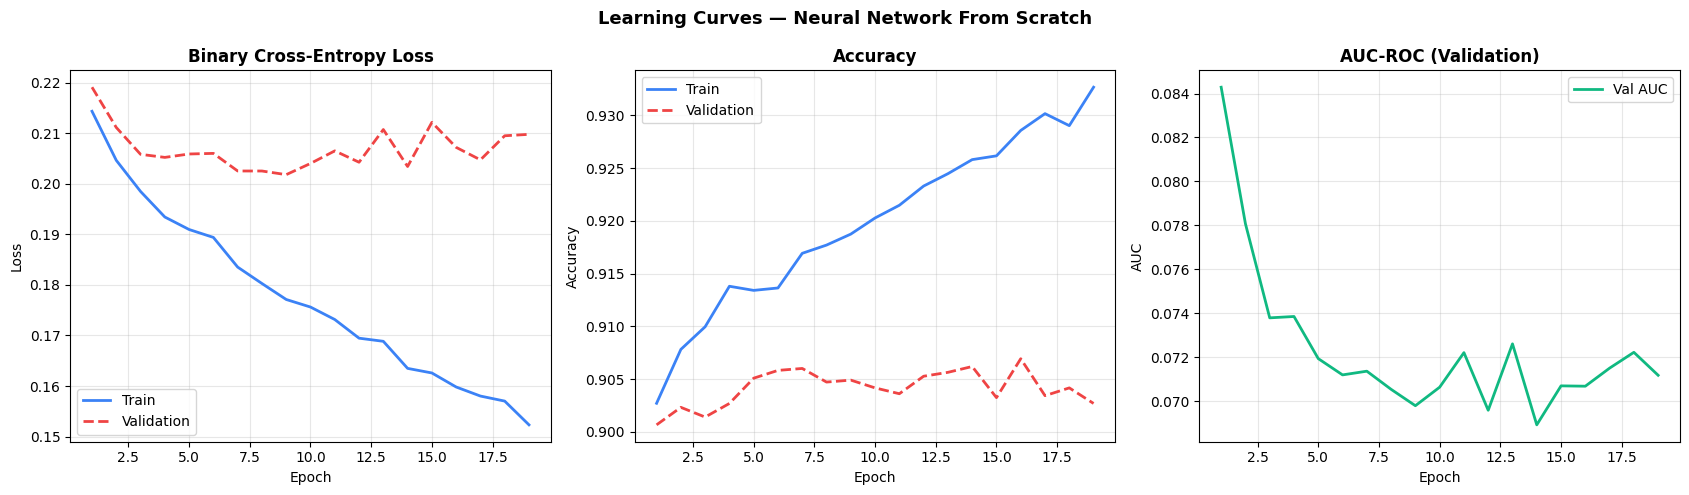

✅ Learning curves selesai.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Learning Curves — Neural Network From Scratch', fontsize=13, fontweight='bold')

epochs_ran = list(range(1, len(history['train_loss'])+1))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], '#3b82f6', lw=2, label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   '#ef4444', lw=2, ls='--', label='Validation')
axes[0].set_title('Binary Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], '#3b82f6', lw=2, label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   '#ef4444', lw=2, ls='--', label='Validation')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs_ran, history['val_auc'], '#10b981', lw=2, label='Val AUC')
axes[2].set_title('AUC-ROC (Validation)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Learning curves selesai.")


## 9. 📊 Evaluasi Model pada Test Set

In [21]:
# Prediksi pada test set menggunakan best_params
y_prob, _ = forward_propagation(X_test, best_params)
y_pred    = (y_prob >= 0.5).astype(int)

# Hitung metrik manual
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_recall_f1(y_true, y_pred):
    TP = ((y_pred==1) & (y_true==1)).sum()
    FP = ((y_pred==1) & (y_true==0)).sum()
    FN = ((y_pred==0) & (y_true==1)).sum()
    TN = ((y_pred==0) & (y_true==0)).sum()
    prec = TP / (TP + FP + 1e-8)
    rec  = TP / (TP + FN + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    spec = TN / (TN + FP + 1e-8)
    return prec, rec, f1, spec, TP, FP, FN, TN

acc                             = accuracy(y_test, y_pred)
prec, rec, f1, spec, TP,FP,FN,TN = precision_recall_f1(y_test, y_pred)
auc                             = roc_auc_score(y_test, y_prob)
loss                            = binary_cross_entropy(y_test, y_prob)

print("=" * 50)
print("     HASIL EVALUASI — TEST SET")
print("=" * 50)
print(f"  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  Specificity : {spec:.4f}")
print(f"  F1-Score    : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}")
print(f"  BCE Loss    : {loss:.4f}")
print("=" * 50)
print(f"\n  TP={int(TP):,}  FP={int(FP):,}  FN={int(FN):,}  TN={int(TN):,}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No (0)','Yes (1)']))


     HASIL EVALUASI — TEST SET
  Accuracy    : 0.9043  (90.43%)
  Precision   : 0.6331
  Recall      : 0.4338
  Specificity : 0.9667
  F1-Score    : 0.5149
  AUC-ROC     : 0.9228
  BCE Loss    : 0.2115

  TP=459  FP=266  FN=599  TN=7,719

=== Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.93      0.97      0.95      7985
     Yes (1)       0.63      0.43      0.51      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.70      0.73      9043
weighted avg       0.89      0.90      0.90      9043



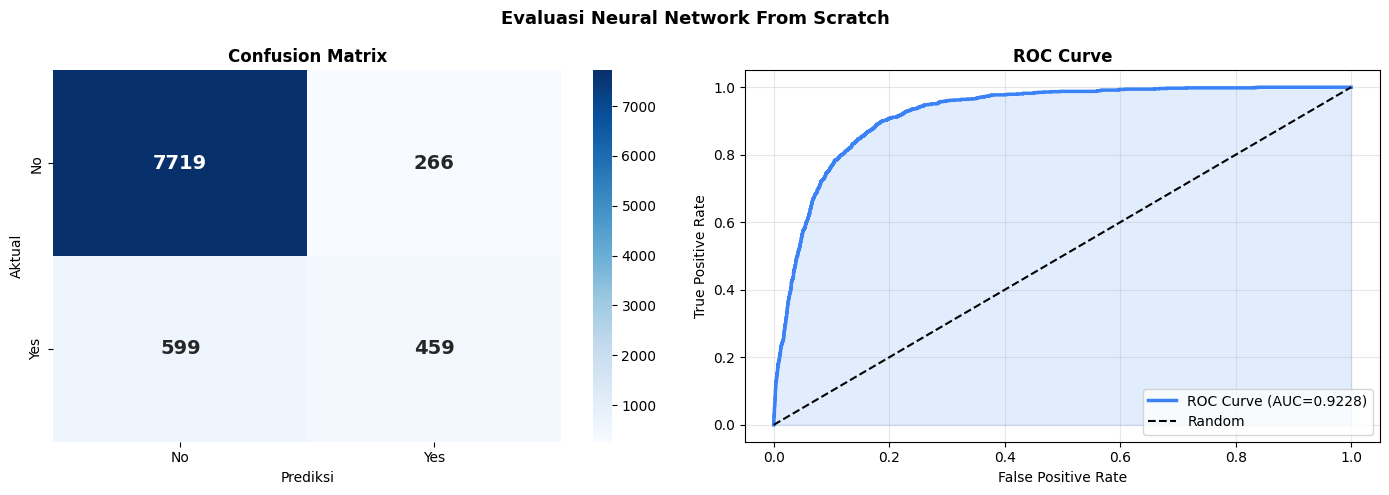

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Neural Network From Scratch', fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, '#3b82f6', lw=2.5, label=f'ROC Curve (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#3b82f6')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Visualisasi Bobot Neural Network

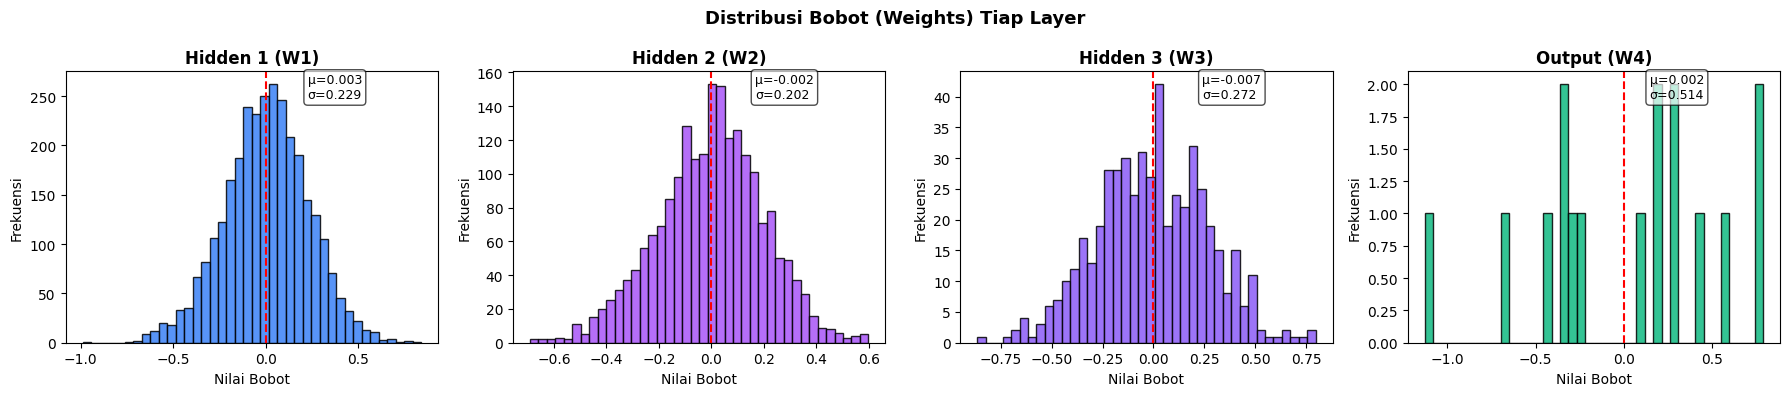

✅ Distribusi bobot divisualisasikan.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribusi Bobot (Weights) Tiap Layer', fontsize=13, fontweight='bold')

layer_names = ['Hidden 1 (W1)', 'Hidden 2 (W2)', 'Hidden 3 (W3)', 'Output (W4)']
colors = ['#3b82f6', '#a855f7', '#8b5cf6', '#10b981']

for i, (name, color) in enumerate(zip(layer_names, colors), start=1):
    W = best_params[f'W{i}'].flatten()
    axes[i-1].hist(W, bins=40, color=color, edgecolor='black', alpha=0.85)
    axes[i-1].set_title(name, fontweight='bold')
    axes[i-1].set_xlabel('Nilai Bobot')
    axes[i-1].set_ylabel('Frekuensi')
    axes[i-1].axvline(0, color='red', ls='--', lw=1.5, label='W=0')
    axes[i-1].text(0.65, 0.9, f'μ={W.mean():.3f}\nσ={W.std():.3f}',
                   transform=axes[i-1].transAxes, fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('weights_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Distribusi bobot divisualisasikan.")


## 11. Demo Prediksi Nasabah Baru

In [ ]:
sample_idx  = np.random.choice(len(X_test), 8, replace=False)
X_sample    = X_test[sample_idx]
y_sample    = y_test[sample_idx]
prob_sample, _ = forward_propagation(X_sample, best_params)
pred_sample = (prob_sample >= 0.5).astype(int)

print("=" * 65)
print("  DEMO PREDIKSI NASABAH BARU")
print("=" * 65)
print(f"{'No':>3} | {'Aktual':>8} | {'Prediksi':>10} | {'Probabilitas':>14} | {'Status':>8}")
print("-" * 65)
for i in range(len(sample_idx)):
    aktual   = 'Yes' if y_sample[i] == 1 else 'No'
    prediksi = 'Yes' if pred_sample[i] == 1 else 'No'
    prob     = prob_sample[i]
    status   = ' Benar' if y_sample[i] == pred_sample[i] else ' Salah'
    print(f"  {i+1} | {aktual:>8} | {prediksi:>10} | {prob:>13.2%} | {status}")
print("=" * 65)


  DEMO PREDIKSI NASABAH BARU
 No |   Aktual |   Prediksi |   Probabilitas |   Status
-----------------------------------------------------------------
  1 |       No |         No |         0.28% | ✅ Benar
  2 |       No |         No |         1.03% | ✅ Benar
  3 |       No |         No |         0.07% | ✅ Benar
  4 |      Yes |         No |         4.97% | ❌ Salah
  5 |       No |         No |         1.74% | ✅ Benar
  6 |       No |         No |         0.01% | ✅ Benar
  7 |       No |         No |         0.11% | ✅ Benar
  8 |       No |         No |         0.12% | ✅ Benar
